# Evaluate similarity suggestions

In [1]:
%load_ext autoreload

In [2]:

import pickle
from os.path import join

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, display_html

In [3]:
%autoreload
from sconnect.dataset_ot import DatasetMapping

## Load and preprocess data

In [4]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"
MODEL_DIR = "/vol/data/dataset-similarity/models/similarityOT"
CACHE_DIR = "/vol/data/dataset-similarity/cache"
FIG_DIR = "/vol/data/dataset-similarity/figures"

QUERY_DATASET = "71f4bccf-53d4-4c12-9e80-e73bfb89e398"
REF_DATASET = "0f528c8a-a25c-4840-8fa3-d156fa11086f"
N_TOP_GENES = 750

In [5]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [6]:
MODEL_VERSION = (
    f"{QUERY_DATASET}+{REF_DATASET}"
    "+n_genes_ova=10"
    "+n_genes_ava=3"
    "+tau=1.0"
    "+epsilon=0.05"
    "+overlap_threshold_ava=0.3"
    "+overlap_n_genes_ava=10"
)

mapping = pd.read_parquet(join(MODEL_DIR, MODEL_VERSION, "mapping_mean.parquet"))
distance = pd.read_parquet(join(MODEL_DIR, MODEL_VERSION, "distance.parquet"))

In [7]:
def extract_ontology_mapping(adata):
    return (
        adata.obs[["cell_type_author", "cell_type"]]
        .drop_duplicates()
        .set_index("cell_type_author")["cell_type"]
        .to_dict()
    )


ontology_mapping_query = extract_ontology_mapping(adata_query)
ontology_mapping_ref = extract_ontology_mapping(adata_ref)

## Select most similar clusters

In [8]:
top_n_labels = DatasetMapping.select_most_similar_clusters(
    mapping, 
    distance, 
    threshold_mapping=0.25,
    threshold_distance=1.,
    n_top=None
)
top_n_labels

{'Arterial VECs': ['EC-AEA'],
 'B.Cells': ['B'],
 'Capillary VECs': [],
 'Cells in the cell cycle (mixed cells)': ['cycEPI', 'cycMNP'],
 'Conventional dendritic cells': ['MDC', 'cDC', 'cycMNP'],
 'Fibroblast 1': ['dFIB', 'aFIB'],
 'Fibroblast 2': ['MyoF', 'FIB'],
 'Gamma delta-T cells': [],
 'Langerhans cells': ['cDC'],
 'Lining mucosal keratinocyte': [],
 'Lymphatic endothelial cell 1': [],
 'Lymphatic endothelial cell 2': [],
 'Macrophages/Monocytes': ['MAC-M2', 'MDC'],
 'Mast cells': ['MAST'],
 'Masticatory mucosal keratinocyte': [],
 'Melanocytes': [],
 'Merkel Cells': [],
 'Mucosal-associated invariant T cells': ['cycT'],
 'NK cells': ['NKT', 'NK1'],
 'NKT cells': ['NK1'],
 'Neutrophils': ['ncMON', 'MON'],
 'Pericytes': ['dVSMC', 'VSMC'],
 'Plasma cells': ['PL'],
 'Plasmacytoid dendritic cells': ['pDC'],
 'Post-capillary venule VECs': ['EC-LYM'],
 'Schwann cells': [],
 'Sulcus/junction epithelial keratinocytes': [],
 'Suprabasal keratinocytes': [],
 'Tc cells': ['T-CYT'],
 'Th cel

#### Author provided cluster labels

In [9]:
summaries = []
for i, (k, v) in enumerate(top_n_labels.items()):
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))

*1*: **Arterial VECs**: ['EC-AEA'] <br>*2*: **B.Cells**: ['B'] <br>*3*: **Capillary VECs**: [] <br>*4*: **Cells in the cell cycle (mixed cells)**: ['cycEPI', 'cycMNP'] <br>*5*: **Conventional dendritic cells**: ['MDC', 'cDC', 'cycMNP'] <br>*6*: **Fibroblast 1**: ['dFIB', 'aFIB'] <br>*7*: **Fibroblast 2**: ['MyoF', 'FIB'] <br>*8*: **Gamma delta-T cells**: [] <br>*9*: **Langerhans cells**: ['cDC'] <br>*10*: **Lining mucosal keratinocyte**: [] <br>*11*: **Lymphatic endothelial cell 1**: [] <br>*12*: **Lymphatic endothelial cell 2**: [] <br>*13*: **Macrophages/Monocytes**: ['MAC-M2', 'MDC'] <br>*14*: **Mast cells**: ['MAST'] <br>*15*: **Masticatory mucosal keratinocyte**: [] <br>*16*: **Melanocytes**: [] <br>*17*: **Merkel Cells**: [] <br>*18*: **Mucosal-associated invariant T cells**: ['cycT'] <br>*19*: **NK cells**: ['NKT', 'NK1'] <br>*20*: **NKT cells**: ['NK1'] <br>*21*: **Neutrophils**: ['ncMON', 'MON'] <br>*22*: **Pericytes**: ['dVSMC', 'VSMC'] <br>*23*: **Plasma cells**: ['PL'] <br>*24*: **Plasmacytoid dendritic cells**: ['pDC'] <br>*25*: **Post-capillary venule VECs**: ['EC-LYM'] <br>*26*: **Schwann cells**: [] <br>*27*: **Sulcus/junction epithelial keratinocytes**: [] <br>*28*: **Suprabasal keratinocytes**: [] <br>*29*: **Tc cells**: ['T-CYT'] <br>*30*: **Th cells**: ['T'] <br>*31*: **Th17 cells**: [] <br>*32*: **Treg cells**: [] <br>*33*: **Vascular smooth muscle cells**: ['VSMC/P'] <br>

#### Ontology mapped cluster labels

In [10]:
summaries = []
for i, (k, v) in enumerate(top_n_labels.items()):
    summaries.append(
        f"*{i+1}*: **{ontology_mapping_query[k]}**: {[ontology_mapping_ref[elem] for elem in v]} <br>"
    )

display(Markdown("".join(summaries)))

*1*: **endothelial cell of artery**: ['endothelial cell'] <br>*2*: **B cell**: ['B cell'] <br>*3*: **capillary endothelial cell**: [] <br>*4*: **keratinocyte**: ['epithelial cell of proximal tubule', 'mononuclear phagocyte'] <br>*5*: **conventional dendritic cell**: ['mononuclear phagocyte', 'conventional dendritic cell', 'mononuclear phagocyte'] <br>*6*: **fibroblast**: ['kidney interstitial cell', 'kidney interstitial cell'] <br>*7*: **fibroblast**: ['kidney interstitial cell', 'kidney interstitial cell'] <br>*8*: **gamma-delta T cell**: [] <br>*9*: **Langerhans cell**: ['conventional dendritic cell'] <br>*10*: **keratinocyte**: [] <br>*11*: **endothelial cell of lymphatic vessel**: [] <br>*12*: **endothelial cell of lymphatic vessel**: [] <br>*13*: **macrophage**: ['kidney interstitial alternatively activated macrophage', 'mononuclear phagocyte'] <br>*14*: **mast cell**: ['mast cell'] <br>*15*: **keratinocyte**: [] <br>*16*: **melanocyte**: [] <br>*17*: **Merkel cell**: [] <br>*18*: **mucosal invariant T cell**: ['T cell'] <br>*19*: **natural killer cell**: ['mature NK T cell', 'natural killer cell'] <br>*20*: **mature NK T cell**: ['natural killer cell'] <br>*21*: **neutrophil**: ['non-classical monocyte', 'monocyte'] <br>*22*: **pericyte**: ['kidney interstitial cell', 'kidney interstitial cell'] <br>*23*: **plasma cell**: ['plasma cell'] <br>*24*: **plasmacytoid dendritic cell**: ['plasmacytoid dendritic cell, human'] <br>*25*: **endothelial cell of venule**: ['endothelial cell'] <br>*26*: **Schwann cell**: [] <br>*27*: **keratinocyte**: [] <br>*28*: **keratinocyte**: [] <br>*29*: **T cell**: ['cytotoxic T cell'] <br>*30*: **helper T cell**: ['T cell'] <br>*31*: **T-helper 17 cell**: [] <br>*32*: **regulatory T cell**: [] <br>*33*: **vascular associated smooth muscle cell**: ['kidney collecting duct intercalated cell'] <br>

## Evaluate cluster similarity

In [11]:
%autoreload
from sconnect.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [12]:
de_res = {}
for name, adata in [("query", adata_query), ("ref", adata_ref)]:
    de_res[name] = {}
    for selection, n_ova, n_ava, auroc, log_fc, p_val, filtering, remove_duplicates, overlap_thres in [
        ("top_DE_genes", 10, 3, 0.5, 1., 0.05, True, True, 0.3), 
        ("all_DE_genes", None, None, 0.5, 0.25, 0.05, True, True, 0.3),
        ("all_genes", None, None, 0., -np.Inf, 1., False, False, 0.1),
    ]:
        res = select_and_combine_de_results(
            sort_and_filter_de_genes_ova(
                adata.uns["de_res_ova"],
                gene_filtering=filtering,
                logfc_threshold=log_fc,
                aucroc_threshold=auroc,
                adj_pval_threshold=p_val,
            ),
            sort_and_filter_de_genes_ava(
                adata.uns["de_res_ava"],
                gene_filtering=filtering,
                logfc_threshold=log_fc,
                aucroc_threshold=auroc,
                adj_pval_threshold=p_val,
            ),
            n_genes_ova=n_ova,
            n_genes_ava=n_ava,
            overlap_threshold=overlap_thres,
            overlap_n_genes=10,
            remove_duplicated_genes=remove_duplicates
        )
        for ct in res:  
            res[ct].index.name = "gene"
            res[ct] = res[ct].reset_index().rename(columns={"index": "gene"})
        de_res[name][selection] = res


In [13]:
def to_hex(m, val):
    rgba = m.to_rgba(val)
    r, g, b, _ = rgba
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))


def style_map_val(v, props=""):
    m = cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0.0, vmax=1.0), 
        cmap=plt.get_cmap("Greens")
    )
    return f"background:{to_hex(m, v)};"


def style_dist_val(v, props=""):
    m = cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0.0, vmax=2.0), 
        cmap=plt.get_cmap("RdYlGn_r")
    )
    return f"background:{to_hex(m, v)};"


def highlight_large(val):
    return "font-size: 30pt"


def style_overlap(v, de_res_top, de_res_all, props=""):
    matches_top = de_res_top.gene.tolist()
    matches_all = de_res_all.gene.tolist()
    if v in matches_top:
        return "color:green;"
    elif v in matches_all:
        return "color:orange;"
    else:
        return "color:red;"


def format_index(df, markers):
    index = np.where(
        df.gene.isin(markers).to_numpy(),
        df.index.astype(str) + " (REF)",
        df.index.astype(str),
    )
    return df.set_index(index)


In [14]:
FONT_SIZE = 14


for k, v in top_n_labels.items():
    html = [f"<h1> <b>{k}</b>: </h1>"]
    if v:
        # Add summary for suggestions
        html_suggestions = []
        ct_name, map_vals, dist_vals = [], [], []
        for s in v:
            ct_name.append(s)
            map_vals.append(mapping.loc[k][s])
            dist_vals.append(distance.loc[k][s])
        html_suggestions.append(
            pd.DataFrame({"OT mass": map_vals, "Distance": dist_vals}, index=ct_name)
            .style
            .set_table_styles([
                {"selector": "tbody th", "props": [("font-size", f"{FONT_SIZE}pt")]},
                {"selector": "td", "props": [("font-size", f"{FONT_SIZE}pt")]}
            ])
            .format("{:.2f}")
            .map(style_map_val, subset=["OT mass"])
            .map(style_dist_val, subset=["Distance"])
            .set_table_attributes("style='display:inline'")
            .to_html()
        )
        html_suggestions.append("<br /><br />")
        # Add summary for differentially expressed genes
        html_de_overlap = []
        for de_query, de_ref in [(de_res["query"], de_res["ref"])]:
            html_de_overlap += [
                de_query["top_DE_genes"][k]
                .drop_duplicates(subset="gene", keep="first")
                .style
                .set_properties(**{"font-size": f"{FONT_SIZE}pt"})
                .format("{:.2f}", subset=["logFC", "auroc"])
                .format("{:.3f}", subset=["adj.P.Val"])
                .map(
                    style_overlap, 
                    subset=["gene"], 
                    de_res_top=de_ref["top_DE_genes"][v[0]],
                    de_res_all=de_ref["all_DE_genes"][v[0]]
                )
                .set_table_attributes("style='display:inline'")
                .set_table_styles({
                    "reference": [{"selector": "", "props": [("white-space", "normal"), ("width", "150px")]}]
                })
                .set_properties(subset=["reference"], **{"text-align": "left", "font-size": "8pt"})
                .set_caption(f'<span style="font-size: {FONT_SIZE}pt;">QUERY - {k}</span>')
                .to_html()
            ]
            html_de_overlap += [
                de_ref["top_DE_genes"][cluster]
                .drop_duplicates(subset="gene", keep="first")
                .style
                .set_properties(**{"font-size": f"{FONT_SIZE}pt"})
                .set_properties(subset=["reference"], **{"text-align": "left", "font-size": "8pt"})
                .format("{:.2f}", subset=["logFC", "auroc"])
                .format("{:.3f}", subset=["adj.P.Val"])
                .map(
                    style_overlap, 
                    subset=["gene"], 
                    de_res_top=de_query["top_DE_genes"][k],
                    de_res_all=de_query["all_DE_genes"][k]
                )
                .set_table_attributes("style='display:inline'")
                .set_table_styles({
                    "reference": [{"selector": "", "props": [("white-space", "normal"), ("width", "150px")]}]
                })
                .set_caption(f'<span style="font-size: {FONT_SIZE}pt;">REF - {cluster}</span>')
                .to_html()
                for cluster in v
            ]
            html_de_overlap.append("<br /><br />")

        html = html + html_suggestions + html_de_overlap
    else:
        html = html + ["<b><i>No matches found</i></b>"]

    display_html("".join(html) + "<br>", raw=True)


Arterial VECs : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 EC-AEA 
 1.00 
 0.72 
 
 
 
 
 
 QUERY - Arterial VECs 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 CLDN5 
 4.29 
 0.000 
 0.88 
 ['all'] 
 
 
 1 
 RAMP2 
 3.88 
 0.000 
 0.89 
 ['all'] 
 
 
 2 
 A2M 
 3.84 
 0.000 
 0.88 
 ['all'] 
 
 
 3 
 IFI27 
 3.83 
 0.000 
 0.90 
 ['all'] 
 
 
 4 
 TM4SF1 
 3.79 
 0.000 
 0.91 
 ['all'] 
 
 
 5 
 PODXL 
 3.72 
 0.000 
 0.85 
 ['all'] 
 
 
 6 
 CLEC14A 
 3.71 
 0.000 
 0.84 
 ['all'] 
 
 
 7 
 CXCL12 
 3.69 
 0.000 
 0.80 
 ['all'] 
 
 
 8 
 IGFBP3 
 3.67 
 0.000 
 0.77 
 ['all'] 
 
 
 9 
 NHERF2 
 3.63 
 0.000 
 0.87 
 ['all'] 
 
 
 

 
 REF - EC-AEA 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 IFI27 
 4.50 
 0.000 
 0.90 
 ['all'] 
 
 
 1 
 RAMP2 
 4.37 
 0.000 
 0.89 
 ['all'] 
 
 
 2 
 CLDN5 
 4.31 
 0.000 
 0.90 
 ['all'] 
 
 
 3 
 NHERF2 
 4.29 
 0.000 
 0.88 
 ['all'] 
 
 
 4 
 AQP1 
 4.25 
 0.000 
 0.81 
 ['all'] 
 
 
 5 
 TIMP3 
 4.21 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 RNASE1 
 4.16 
 0.000 
 0.87 
 ['all'] 
 
 
 7 
 ADGRL4 
 4.10 
 0.000 
 0.87 
 ['all'] 
 
 
 8 
 ADAMTS6 
 4.09 
 0.000 
 0.81 
 ['all'] 
 
 
 9 
 PTPRB 
 3.92 
 0.000 
 0.85 
 ['all']

B.Cells : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 B 
 1.00 
 0.72 
 
 
 
 
 
 QUERY - B.Cells 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 MS4A1 
 4.54 
 0.000 
 0.92 
 ['all'] 
 
 
 1 
 CD79A 
 3.84 
 0.000 
 0.83 
 ['all'] 
 
 
 2 
 BANK1 
 3.48 
 0.000 
 0.82 
 ['all'] 
 
 
 3 
 HLA-DRA 
 3.44 
 0.000 
 0.92 
 ['all'] 
 
 
 4 
 HLA-DQA1 
 3.12 
 0.000 
 0.85 
 ['all'] 
 
 
 5 
 IGHM 
 3.05 
 0.000 
 0.65 
 ['all'] 
 
 
 6 
 HLA-DQB1 
 2.96 
 0.000 
 0.84 
 ['all'] 
 
 
 7 
 TNFRSF13C 
 2.95 
 0.000 
 0.75 
 ['all'] 
 
 
 8 
 CD83 
 2.87 
 0.000 
 0.74 
 ['all'] 
 
 
 9 
 LTB 
 2.84 
 0.000 
 0.77 
 ['all'] 
 
 
 

 
 REF - B 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 IGKC 
 5.63 
 0.000 
 0.83 
 ['all'] 
 
 
 1 
 IGHM 
 4.82 
 0.000 
 0.80 
 ['all'] 
 
 
 2 
 MS4A1 
 4.48 
 0.000 
 0.92 
 ['all'] 
 
 
 3 
 CD79A 
 3.99 
 0.000 
 0.85 
 ['all'] 
 
 
 4 
 LTB 
 3.96 
 0.000 
 0.89 
 ['all'] 
 
 
 5 
 CD37 
 3.93 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 IGLC2 
 3.87 
 0.000 
 0.66 
 ['all'] 
 
 
 7 
 CD52 
 3.86 
 0.000 
 0.90 
 ['all'] 
 
 
 8 
 BANK1 
 3.84 
 0.000 
 0.84 
 ['all'] 
 
 
 9 
 CD79B 
 3.41 
 0.000 
 0.79 
 ['all']

Capillary VECs : No matches found

Cells in the cell cycle (mixed cells) : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 cycEPI 
 1.00 
 0.49 
 
 
 cycMNP 
 0.33 
 0.83 
 
 
 
 
 
 QUERY - Cells in the cell cycle (mixed cells) 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 PCLAF 
 3.40 
 0.000 
 0.91 
 ['all'] 
 
 
 1 
 STMN1 
 3.10 
 0.000 
 0.94 
 ['all'] 
 
 
 2 
 ASPM 
 2.98 
 0.000 
 0.79 
 ['all'] 
 
 
 3 
 TK1 
 2.81 
 0.000 
 0.83 
 ['all'] 
 
 
 4 
 H4C3 
 2.73 
 0.000 
 0.85 
 ['all'] 
 
 
 5 
 CDKN3 
 2.69 
 0.000 
 0.79 
 ['all'] 
 
 
 6 
 ZWINT 
 2.63 
 0.000 
 0.82 
 ['all'] 
 
 
 7 
 PTTG1 
 2.57 
 0.000 
 0.86 
 ['all'] 
 
 
 8 
 PRC1 
 2.46 
 0.000 
 0.80 
 ['all'] 
 
 
 9 
 PBK 
 2.46 
 0.000 
 0.78 
 ['all'] 
 
 
 

 
 REF - cycEPI 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 PCLAF 
 3.21 
 0.000 
 0.78 
 ['all'] 
 
 
 1 
 PTTG1 
 3.03 
 0.000 
 0.70 
 ['all'] 
 
 
 2 
 STMN1 
 2.99 
 0.000 
 0.80 
 ['all'] 
 
 
 3 
 MMP7 
 2.79 
 0.000 
 0.71 
 ['all'] 
 
 
 4 
 TK1 
 2.68 
 0.000 
 0.69 
 ['all'] 
 
 
 5 
 CCNB1 
 2.39 
 0.000 
 0.64 
 ['all'] 
 
 
 6 
 CDKN3 
 2.34 
 0.000 
 0.65 
 ['all'] 
 
 
 7 
 PBK 
 2.33 
 0.000 
 0.66 
 ['all'] 
 
 
 8 
 H2AZ1 
 2.32 
 0.000 
 0.80 
 ['all'] 
 
 
 9 
 CENPM 
 2.28 
 0.000 
 0.66 
 ['all'] 
 
 
 

 
 REF - cycMNP 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 LYZ 
 4.33 
 0.000 
 0.87 
 ['all'] 
 
 
 1 
 HLA-DPA1 
 3.61 
 0.000 
 0.91 
 ['all'] 
 
 
 2 
 PCLAF 
 3.57 
 0.000 
 0.91 
 ['MDC', 'all', 'cDC'] 
 
 
 3 
 HLA-DRA 
 3.47 
 0.000 
 0.88 
 ['all'] 
 
 
 4 
 AIF1 
 3.43 
 0.000 
 0.87 
 ['all'] 
 
 
 5 
 STMN1 
 3.40 
 0.000 
 0.95 
 ['MDC', 'all', 'cDC'] 
 
 
 6 
 HLA-DRB1 
 3.29 
 0.000 
 0.89 
 ['all'] 
 
 
 7 
 HLA-DPB1 
 3.25 
 0.000 
 0.89 
 ['all'] 
 
 
 8 
 TYROBP 
 3.02 
 0.000 
 0.79 
 ['all'] 
 
 
 9 
 H4C3 
 3.00 
 0.000 
 0.76 
 ['MDC'] 
 
 
 10 
 HLA-DQB1 
 2.99 
 0.000 
 0.87 
 ['all'] 
 
 
 11 
 TK1 
 2.75 
 0.000 
 0.81 
 ['cDC']

Conventional dendritic cells : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 MDC 
 0.57 
 0.68 
 
 
 cDC 
 0.49 
 0.64 
 
 
 cycMNP 
 0.39 
 0.75 
 
 
 
 
 
 QUERY - Conventional dendritic cells 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 LYZ 
 5.11 
 0.000 
 0.94 
 ['all'] 
 
 
 1 
 HLA-DRA 
 4.49 
 0.000 
 0.96 
 ['all'] 
 
 
 2 
 HLA-DQA1 
 4.42 
 0.000 
 0.94 
 ['all'] 
 
 
 3 
 HLA-DPB1 
 4.21 
 0.000 
 0.96 
 ['all'] 
 
 
 4 
 HLA-DPA1 
 4.18 
 0.000 
 0.95 
 ['all'] 
 
 
 5 
 CPVL 
 4.12 
 0.000 
 0.84 
 ['all'] 
 
 
 6 
 HLA-DQB1 
 4.04 
 0.000 
 0.94 
 ['all'] 
 
 
 7 
 HLA-DRB1 
 3.97 
 0.000 
 0.93 
 ['all'] 
 
 
 8 
 AIF1 
 3.83 
 0.000 
 0.90 
 ['all'] 
 
 
 9 
 LGALS2 
 3.74 
 0.000 
 0.85 
 ['all'] 
 
 
 10 
 DNASE1L3 
 2.31 
 0.000 
 0.60 
 ['Langerhans cells'] 
 
 
 11 
 C1orf54 
 2.19 
 0.000 
 0.61 
 ['Langerhans cells'] 
 
 
 12 
 CLEC9A 
 2.04 
 0.000 
 0.59 
 ['Langerhans cells'] 
 
 
 

 
 REF - MDC 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 LYZ 
 5.13 
 0.000 
 0.93 
 ['all', 'MAC-M2'] 
 
 
 1 
 TYROBP 
 4.40 
 0.000 
 0.95 
 ['all'] 
 
 
 2 
 AIF1 
 4.14 
 0.000 
 0.92 
 ['all'] 
 
 
 3 
 HLA-DRA 
 4.12 
 0.000 
 0.92 
 ['all'] 
 
 
 4 
 HLA-DPA1 
 4.12 
 0.000 
 0.91 
 ['all'] 
 
 
 5 
 C1QA 
 4.03 
 0.000 
 0.76 
 ['all'] 
 
 
 6 
 HLA-DPB1 
 3.99 
 0.000 
 0.91 
 ['all'] 
 
 
 7 
 FCER1G 
 3.78 
 0.000 
 0.92 
 ['all'] 
 
 
 8 
 HLA-DRB1 
 3.73 
 0.000 
 0.91 
 ['all'] 
 
 
 9 
 C1QB 
 3.72 
 0.000 
 0.71 
 ['all'] 
 
 
 10 
 FCN1 
 2.64 
 0.000 
 0.68 
 ['MAC-M2', 'cycMNP', 'cDC'] 
 
 
 11 
 CFD 
 2.19 
 0.000 
 0.69 
 ['cycMNP'] 
 
 
 12 
 LPAR6 
 2.18 
 0.000 
 0.66 
 ['cycMNP'] 
 
 
 13 
 S100A9 
 1.96 
 0.000 
 0.70 
 ['cDC'] 
 
 
 14 
 S100A8 
 1.87 
 0.000 
 0.65 
 ['cDC'] 
 
 
 15 
 IL1B 
 1.81 
 0.000 
 0.69 
 ['MAC-M2'] 
 
 
 

 
 REF - cDC 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 LYZ 
 4.89 
 0.000 
 0.93 
 ['all'] 
 
 
 1 
 HLA-DPA1 
 4.61 
 0.000 
 0.97 
 ['all'] 
 
 
 2 
 HLA-DRA 
 4.55 
 0.000 
 0.98 
 ['all'] 
 
 
 3 
 HLA-DPB1 
 4.55 
 0.000 
 0.98 
 ['all'] 
 
 
 4 
 HLA-DQA1 
 4.31 
 0.000 
 0.95 
 ['all'] 
 
 
 5 
 TYROBP 
 4.22 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 HLA-DQB1 
 4.17 
 0.000 
 0.95 
 ['all'] 
 
 
 7 
 HLA-DRB1 
 4.17 
 0.000 
 0.96 
 ['all'] 
 
 
 8 
 AIF1 
 3.94 
 0.000 
 0.92 
 ['all'] 
 
 
 9 
 FCER1A 
 3.76 
 0.000 
 0.76 
 ['all', 'cycMNP', 'MDC'] 
 
 
 10 
 CLEC10A 
 2.36 
 0.000 
 0.67 
 ['cycMNP'] 
 
 
 11 
 LPAR6 
 1.93 
 0.000 
 0.60 
 ['cycMNP'] 
 
 
 12 
 CD1C 
 1.67 
 0.000 
 0.58 
 ['MDC'] 
 
 
 13 
 CD1E 
 1.47 
 0.000 
 0.57 
 ['MDC'] 
 
 
 

 
 REF - cycMNP 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 LYZ 
 4.33 
 0.000 
 0.87 
 ['all'] 
 
 
 1 
 HLA-DPA1 
 3.61 
 0.000 
 0.91 
 ['all'] 
 
 
 2 
 PCLAF 
 3.57 
 0.000 
 0.91 
 ['MDC', 'all', 'cDC'] 
 
 
 3 
 HLA-DRA 
 3.47 
 0.000 
 0.88 
 ['all'] 
 
 
 4 
 AIF1 
 3.43 
 0.000 
 0.87 
 ['all'] 
 
 
 5 
 STMN1 
 3.40 
 0.000 
 0.95 
 ['MDC', 'all', 'cDC'] 
 
 
 6 
 HLA-DRB1 
 3.29 
 0.000 
 0.89 
 ['all'] 
 
 
 7 
 HLA-DPB1 
 3.25 
 0.000 
 0.89 
 ['all'] 
 
 
 8 
 TYROBP 
 3.02 
 0.000 
 0.79 
 ['all'] 
 
 
 9 
 H4C3 
 3.00 
 0.000 
 0.76 
 ['MDC'] 
 
 
 10 
 HLA-DQB1 
 2.99 
 0.000 
 0.87 
 ['all'] 
 
 
 11 
 TK1 
 2.75 
 0.000 
 0.81 
 ['cDC']

...

Tc cells : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 T-CYT 
 0.61 
 0.47 
 
 
 
 
 
 QUERY - Tc cells 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 CCL5 
 4.46 
 0.000 
 0.93 
 ['all'] 
 
 
 1 
 CCL4 
 4.23 
 0.000 
 0.84 
 ['all'] 
 
 
 2 
 GZMK 
 4.19 
 0.000 
 0.88 
 ['all', 'NKT cells'] 
 
 
 3 
 GZMA 
 4.05 
 0.000 
 0.87 
 ['all'] 
 
 
 4 
 NKG7 
 3.93 
 0.000 
 0.84 
 ['all'] 
 
 
 5 
 GZMH 
 3.53 
 0.000 
 0.66 
 ['all'] 
 
 
 6 
 CD3D 
 3.48 
 0.000 
 0.81 
 ['all'] 
 
 
 7 
 CD8A 
 3.37 
 0.000 
 0.74 
 ['all'] 
 
 
 8 
 CST7 
 3.26 
 0.000 
 0.81 
 ['all'] 
 
 
 9 
 CCL4L2 
 3.17 
 0.000 
 0.64 
 ['all'] 
 
 
 10 
 CCR7 
 1.25 
 0.000 
 0.54 
 ['NKT cells'] 
 
 
 11 
 HNRNPLL 
 1.06 
 0.000 
 0.52 
 ['NKT cells'] 
 
 
 

 
 REF - T-CYT 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 CCL5 
 5.16 
 0.000 
 0.97 
 ['all', 'cycT'] 
 
 
 1 
 NKG7 
 4.63 
 0.000 
 0.91 
 ['all'] 
 
 
 2 
 GZMA 
 4.62 
 0.000 
 0.94 
 ['all'] 
 
 
 3 
 CCL4 
 4.48 
 0.000 
 0.86 
 ['all'] 
 
 
 4 
 CD3D 
 4.27 
 0.000 
 0.91 
 ['all'] 
 
 
 5 
 TRBC2 
 4.04 
 0.000 
 0.87 
 ['all'] 
 
 
 6 
 CD2 
 3.96 
 0.000 
 0.88 
 ['all'] 
 
 
 7 
 HCST 
 3.95 
 0.000 
 0.94 
 ['all'] 
 
 
 8 
 GZMH 
 3.95 
 0.000 
 0.81 
 ['all'] 
 
 
 9 
 GZMK 
 3.90 
 0.000 
 0.77 
 ['all', 'NK1', 'cycT'] 
 
 
 10 
 CD8B 
 2.30 
 0.000 
 0.55 
 ['cycT'] 
 
 
 11 
 LTB 
 2.16 
 0.000 
 0.67 
 ['NK1'] 
 
 
 12 
 TRAC 
 2.01 
 0.000 
 0.77 
 ['NK1']

Th cells : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 T 
 0.99 
 0.46 
 
 
 
 
 
 QUERY - Th cells 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 IL7R 
 3.17 
 0.000 
 0.77 
 ['all'] 
 
 
 1 
 TRAC 
 3.15 
 0.000 
 0.79 
 ['all'] 
 
 
 2 
 CD3D 
 3.09 
 0.000 
 0.80 
 ['all'] 
 
 
 3 
 TRBC2 
 3.01 
 0.000 
 0.74 
 ['all'] 
 
 
 4 
 LTB 
 2.95 
 0.000 
 0.76 
 ['all'] 
 
 
 5 
 TRBC1 
 2.94 
 0.000 
 0.68 
 ['all'] 
 
 
 6 
 CD2 
 2.87 
 0.000 
 0.76 
 ['all'] 
 
 
 7 
 KLRB1 
 2.77 
 0.000 
 0.65 
 ['all'] 
 
 
 8 
 CD3G 
 2.70 
 0.000 
 0.69 
 ['all'] 
 
 
 9 
 CD3E 
 2.70 
 0.000 
 0.70 
 ['all'] 
 
 
 10 
 CCL5 
 2.48 
 0.000 
 0.59 
 ['Treg cells'] 
 
 
 11 
 GZMK 
 2.34 
 0.000 
 0.56 
 ['Treg cells', 'Th17 cells'] 
 
 
 12 
 KLF2 
 1.84 
 0.000 
 0.61 
 ['Treg cells', 'Th17 cells'] 
 
 
 13 
 TSHZ2 
 1.75 
 0.000 
 0.56 
 ['Mucosal-associated invariant T cells'] 
 
 
 14 
 CCL4 
 1.40 
 0.000 
 0.51 
 ['Th17 cells'] 
 
 
 15 
 CCR7 
 1.39 
 0.000 
 0.57 
 ['Mucosal-associated invariant T cells'] 
 
 
 16 
 CD4 
 1.33 
 0.000 
 0.55 
 ['Mucosal-associated invariant T cells'] 
 
 
 

 
 REF - T 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 IL7R 
 4.59 
 0.000 
 0.84 
 ['all'] 
 
 
 1 
 CD3D 
 3.82 
 0.000 
 0.85 
 ['all'] 
 
 
 2 
 LTB 
 3.82 
 0.000 
 0.85 
 ['all'] 
 
 
 3 
 CD69 
 3.79 
 0.000 
 0.77 
 ['all'] 
 
 
 4 
 TRBC2 
 3.77 
 0.000 
 0.82 
 ['all'] 
 
 
 5 
 CCL5 
 3.77 
 0.000 
 0.67 
 ['all'] 
 
 
 6 
 CD2 
 3.76 
 0.000 
 0.82 
 ['all'] 
 
 
 7 
 KLRB1 
 3.70 
 0.000 
 0.69 
 ['all'] 
 
 
 8 
 CD52 
 3.63 
 0.000 
 0.86 
 ['all'] 
 
 
 9 
 TRAC 
 3.44 
 0.000 
 0.79 
 ['all']

Th17 cells : No matches found

Treg cells : No matches found

Vascular smooth muscle cells : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 VSMC/P 
 0.98 
 0.77 
 
 
 
 
 
 QUERY - Vascular smooth muscle cells 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 RGS5 
 5.33 
 0.000 
 0.94 
 ['all'] 
 
 
 1 
 NDUFA4L2 
 4.64 
 0.000 
 0.88 
 ['all'] 
 
 
 2 
 TAGLN 
 4.26 
 0.000 
 0.83 
 ['all'] 
 
 
 3 
 ACTA2 
 4.18 
 0.000 
 0.76 
 ['all'] 
 
 
 4 
 MYL9 
 3.93 
 0.000 
 0.84 
 ['all'] 
 
 
 5 
 COL1A1 
 3.82 
 0.000 
 0.72 
 ['all'] 
 
 
 6 
 MGP 
 3.82 
 0.000 
 0.81 
 ['all'] 
 
 
 7 
 CPE 
 3.78 
 0.000 
 0.78 
 ['all'] 
 
 
 8 
 CALD1 
 3.77 
 0.000 
 0.85 
 ['all'] 
 
 
 9 
 COX4I2 
 3.72 
 0.000 
 0.78 
 ['all'] 
 
 
 10 
 COL6A3 
 2.51 
 0.000 
 0.69 
 ['Pericytes'] 
 
 
 11 
 THY1 
 2.43 
 0.000 
 0.71 
 ['Pericytes'] 
 
 
 12 
 CCL19 
 2.32 
 0.000 
 0.57 
 ['Pericytes'] 
 
 
 

 
 REF - VSMC/P 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 RGS5 
 5.62 
 0.000 
 0.98 
 ['all'] 
 
 
 1 
 TAGLN 
 4.33 
 0.000 
 0.91 
 ['all'] 
 
 
 2 
 ACTA2 
 4.03 
 0.000 
 0.86 
 ['all'] 
 
 
 3 
 C11orf96 
 3.98 
 0.000 
 0.84 
 ['all'] 
 
 
 4 
 SLIT3 
 3.93 
 0.000 
 0.87 
 ['all'] 
 
 
 5 
 PLAC9 
 3.76 
 0.000 
 0.88 
 ['all'] 
 
 
 6 
 NDUFA4L2 
 3.76 
 0.000 
 0.82 
 ['all'] 
 
 
 7 
 MYH11 
 3.72 
 0.000 
 0.81 
 ['all'] 
 
 
 8 
 RERGL 
 3.72 
 0.000 
 0.82 
 ['all'] 
 
 
 9 
 MGP 
 3.72 
 0.000 
 0.89 
 ['all'] 
 
 
 10 
 TM4SF1 
 3.19 
 0.000 
 0.82 
 ['VSMC'] 
 
 
 11 
 EMCN 
 2.76 
 0.000 
 0.63 
 ['VSMC', 'dVSMC'] 
 
 
 12 
 ADGRF5 
 2.71 
 0.000 
 0.73 
 ['VSMC', 'dVSMC'] 
 
 
 13 
 DACH1 
 2.02 
 0.000 
 0.65 
 ['dVSMC']

In [40]:
def summary(df):
    print("\n".join([f"{gene.ljust(6)} \t (rank={rank} - logFC={logfc})" for gene, rank, logfc in zip(df.gene, df.index, df.logFC)]))

In [41]:
summary(de_res["ref"]["top_DE_genes"]["cycT"].head(15).round(2))

GZMA   	 (rank=0 - logFC=4.01)
NKG7   	 (rank=1 - logFC=3.93)
STMN1  	 (rank=2 - logFC=3.76)
CORO1A 	 (rank=3 - logFC=3.7)
CD3D   	 (rank=4 - logFC=3.65)
PCLAF  	 (rank=5 - logFC=3.53)
GNLY   	 (rank=6 - logFC=3.52)
TRBC2  	 (rank=7 - logFC=3.4)
CD2    	 (rank=8 - logFC=3.34)
ASPM   	 (rank=9 - logFC=3.29)
PTPRC  	 (rank=10 - logFC=3.27)


In [42]:
summary(
    de_res["ref"]["all_DE_genes"]["cycT"]
    .query(f'`gene` in {["KLRB1", "IL7R", "NCR3", "SLC4A10", "TRAV1-2"]}')
    .round(2)
)

KLRB1  	 (rank=25 - logFC=2.81)
NCR3   	 (rank=254 - logFC=1.45)
IL7R   	 (rank=493 - logFC=1.08)
SLC4A10 	 (rank=2349 - logFC=0.31)


In [43]:
summary(de_res["query"]["top_DE_genes"]["Mucosal-associated invariant T cells"].head(15).round(2))

CCL5   	 (rank=0 - logFC=3.57)
KLRB1  	 (rank=1 - logFC=3.42)
CD3D   	 (rank=2 - logFC=3.38)
TRAC   	 (rank=3 - logFC=3.17)
CD2    	 (rank=4 - logFC=3.08)
GZMA   	 (rank=5 - logFC=3.01)
IL7R   	 (rank=6 - logFC=2.98)
GNLY   	 (rank=7 - logFC=2.96)
CCL4   	 (rank=8 - logFC=2.89)
TRBC2  	 (rank=9 - logFC=2.86)
CD69   	 (rank=10 - logFC=2.83)
CD52   	 (rank=11 - logFC=2.83)
NKG7   	 (rank=12 - logFC=2.19)
GZMB   	 (rank=13 - logFC=1.87)


In [44]:
summary(
    de_res["query"]["all_DE_genes"]["Mucosal-associated invariant T cells"]
    .query(f'`gene` in {["KLRB1", "IL7R", "NCR3", "SLC4A10", "TRAV1-2"]}')
    .round(2)
)

KLRB1  	 (rank=1 - logFC=3.42)
IL7R   	 (rank=6 - logFC=2.98)
NCR3   	 (rank=94 - logFC=1.46)
SLC4A10 	 (rank=285 - logFC=0.86)


## Figure 2: Immune &rarr; Immune Example

In [17]:
def summary(df):
    print("\n".join([f"{gene.ljust(7)} \t (rank={rank})" for gene, rank in zip(df.gene, df.index)]))

### `Plasmacytoid dendritic cells` &rarr; `pDC`

In [46]:
summary(
    de_res["query"]["all_DE_genes"]["Plasmacytoid dendritic cells"]
    .query(f"`gene` in {['IRF8', 'CUX2', 'P2RY14', 'IL3RA', 'CLEC4C', 'LILRA4', 'JCHAIN']}")
    .round(2)
)

JCHAIN  	 (rank=1)
LILRA4  	 (rank=2)
IRF8    	 (rank=4)
CLEC4C  	 (rank=27)
P2RY14  	 (rank=90)
CUX2    	 (rank=606)


In [47]:
summary(
    de_res["ref"]["all_DE_genes"]["pDC"]
    .query(f"`gene` in {['IRF8', 'CUX2', 'P2RY14', 'IL3RA', 'CLEC4C', 'LILRA4', 'JCHAIN']}")
    .round(2)
)

JCHAIN  	 (rank=1)
IRF8    	 (rank=3)
LILRA4  	 (rank=19)
P2RY14  	 (rank=25)
CLEC4C  	 (rank=39)
CUX2    	 (rank=145)


### `Mast cells` &rarr; `MAST`

In [20]:
summary(
    de_res["query"]["all_DE_genes"]["Mast cells"]
    .query(f"`gene` in {['MS4A2', 'CPA3', 'KIT']}")
    .round(2)
)

CPA3    	 (rank=2)
MS4A2   	 (rank=4)
KIT     	 (rank=16)


In [21]:
summary(
    de_res["ref"]["all_DE_genes"]["MAST"]
    .query(f"`gene` in {['MS4A2', 'CPA3', 'KIT']}")
    .round(2)
)

CPA3    	 (rank=2)
MS4A2   	 (rank=5)
KIT     	 (rank=6)


### `Plasma cells` &rarr; `PL`

In [22]:
summary(
    de_res["query"]["all_DE_genes"]["Plasma cells"]
    .query(f"`gene` in {['IGKC', 'TENT5C', 'MZB1', 'FCRL5', 'CD38', 'JCHAIN']}")
    .round(2)
)

IGKC    	 (rank=0)
JCHAIN  	 (rank=9)
MZB1    	 (rank=10)
FCRL5   	 (rank=21)
TENT5C  	 (rank=41)
CD38    	 (rank=43)


In [23]:
summary(
    de_res["ref"]["all_DE_genes"]["PL"]
    .query(f"`gene` in {['IGKC', 'TENT5C', 'MZB1', 'FCRL5', 'CD38', 'JCHAIN']}")
    .round(2)
)

IGKC    	 (rank=0)
JCHAIN  	 (rank=3)
MZB1    	 (rank=8)
FCRL5   	 (rank=22)
CD38    	 (rank=26)
TENT5C  	 (rank=28)


### `B cells` &rarr; `B`

In [24]:
summary(
    de_res["query"]["all_DE_genes"]["B.Cells"]
    .query(f"`gene` in {['BANK1', 'BLK', 'MS4A1', 'BACH2']}")
    .round(2)
)

MS4A1   	 (rank=0)
BANK1   	 (rank=2)
BLK     	 (rank=31)
BACH2   	 (rank=586)


In [25]:
summary(
    de_res["ref"]["all_DE_genes"]["B"]
    .query(f"`gene` in {['BANK1', 'BLK', 'MS4A1', 'BACH2']}")
    .round(2)
)

MS4A1   	 (rank=2)
BANK1   	 (rank=8)
BLK     	 (rank=23)
BACH2   	 (rank=90)


### `Tc cells` &rarr; `T-CYT` & `Th cells` &rarr; `T`

In [19]:
import scanpy as sc

In [20]:
adata_gingiva = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/221dff56-a47d-4563-90ed-51b60e2f16d5.h5ad"
)
adata_kidney = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/1c360b0b-eb2f-45a3-aba9-056026b39fa5.h5ad"
)

In [21]:
del adata_gingiva.raw
del adata_kidney.raw

In [22]:
adata_gingiva.var.index = adata_gingiva.var["feature_name"].astype(str)
adata_kidney.var.index = adata_kidney.var["feature_name"].astype(str)

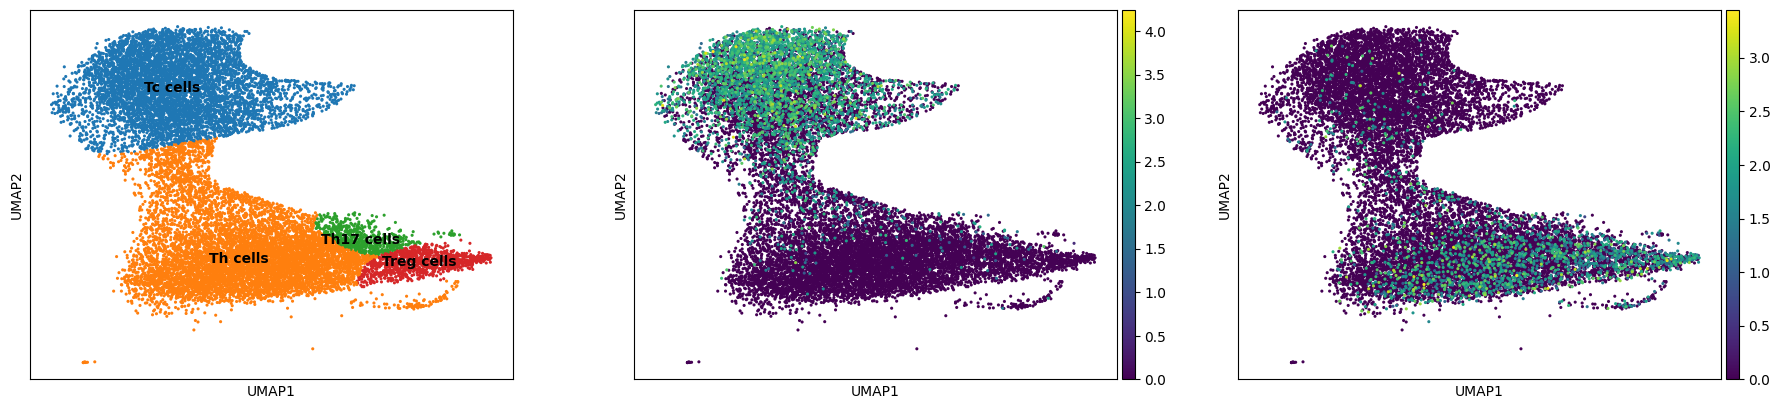

In [26]:
sc.pl.umap(
    adata_gingiva[adata_gingiva.obs["Annotated Cell Sets"].isin(
        ["Tc cells", "Th cells", "Th17 cells", "Treg cells"]
    )].copy(),
    color=["Annotated Cell Sets", "CD8A", "CD4"],
    ncols=3,
    size=20,
    legend_loc="on data",
    title=["", "", ""],
    save="_T_gingiva.png"
)

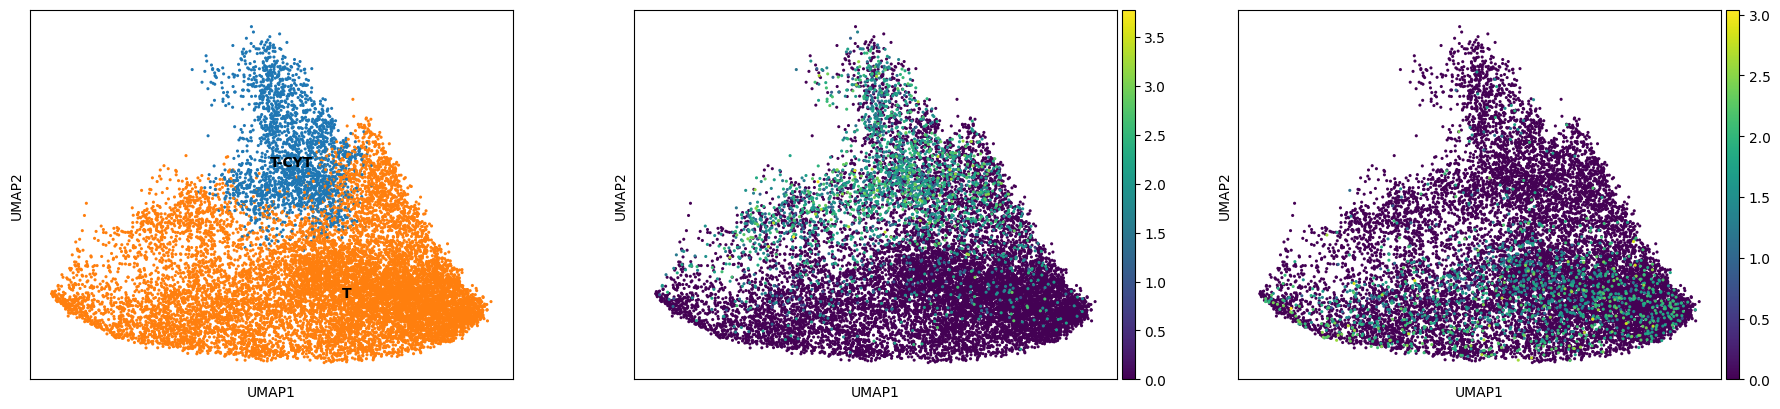

In [25]:
sc.pl.umap(
    adata_kidney[
        adata_kidney.obs["author_cell_type"].isin(["T", "T-CYT"]) & 
        (adata_kidney.obsm["X_umap"][:, 1] > -3.) # filter out outlier values from UMAP
    ].copy(),
    color=["author_cell_type", "CD8A", "CD4"],
    ncols=3,
    size=20,
    legend_loc="on data",
    title=["", "", ""],
    save="_T_kidney.png"
)

### `Th cells` &rarr; `T`

In [61]:
(
    de_res["query"]["all_DE_genes"]["Th cells"]
    .query(f"`gene` in {['CD96', 'CD247', 'THEMIS', 'BCL11B', 'CAMK4', 'IL7R']}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,IL7R,3.17,0.0,0.77,[all]
13,BCL11B,2.54,0.0,0.67,[all]
41,CD96,1.81,0.0,0.57,[all]
46,CD247,1.76,0.0,0.59,[all]
57,CAMK4,1.65,0.0,0.55,"[all, Treg cells]"
125,THEMIS,1.35,0.0,0.53,"[all, Treg cells]"


In [62]:
(
    de_res["ref"]["all_DE_genes"]["T"]
    .query(f"`gene` in {['CD96', 'CD247', 'THEMIS', 'BCL11B', 'CAMK4', 'IL7R']}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,IL7R,4.59,0.0,0.84,[all]
19,CD96,2.87,0.0,0.66,[all]
20,BCL11B,2.86,0.0,0.68,[all]
24,CD247,2.62,0.0,0.64,[all]
25,THEMIS,2.61,0.0,0.63,[all]
28,CAMK4,2.50,0.0,0.62,[all]


### `Plasma cells` &rarr; `PL`

In [26]:
plasma_cell_markers = ["MZB1", "JCHAIN", "TNFRSF17", "ITM2C", "DERL3", "POU2AF1", "IGHA1", "TXNDC11", "CD79A"]

In [27]:
(
    de_res["query"]["all_DE_genes"]["Plasma cells"]
    .query(f"`gene` in {plasma_cell_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
5,IGHA1,3.57,0.00,0.68,[all]
9,JCHAIN,3.37,0.00,0.65,[all]
10,MZB1,2.82,0.00,0.89,[all]
11,DERL3,2.16,0.00,0.83,[all]
12,CD79A,1.99,0.00,0.79,[all]
16,TNFRSF17,1.48,0.00,0.67,[all]
25,POU2AF1,1.07,0.00,0.65,[all]
54,ITM2C,0.67,0.03,0.67,[all]
59,TXNDC11,0.62,0.00,0.63,[all]


In [28]:
(
    de_res["ref"]["all_DE_genes"]["PL"]
    .query(f"`gene` in {plasma_cell_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
3,JCHAIN,6.67,0.0,0.83,[all]
4,IGHA1,6.57,0.0,0.75,[all]
8,MZB1,5.09,0.0,0.98,[all]
11,DERL3,3.97,0.0,0.95,[all]
16,TNFRSF17,3.00,0.0,0.89,[all]
27,CD79A,2.11,0.0,0.73,[all]
31,POU2AF1,1.85,0.0,0.73,[all]
53,ITM2C,1.31,0.0,0.75,[all]
55,TXNDC11,1.28,0.0,0.72,[all]


### `Macrophages/Monocytes` &rarr; `MAC-M2` + `MDC` (MDC = monocyte derived cells)

In [29]:
MAC_M2_markers = ["MRC1", "CD163", "CD14", "CD68", "C1QA", "MRC1"]

In [30]:
(
    de_res["query"]["all_DE_genes"]["Macrophages/Monocytes"]
    .query(f"`gene` in {MAC_M2_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
1,C1QA,4.85,0.0,0.90,[all]
8,CD14,3.80,0.0,0.85,[all]
17,CD68,3.37,0.0,0.81,[all]
37,CD163,2.85,0.0,0.70,[all]
63,MRC1,2.56,0.0,0.67,[all]


In [31]:
(
    de_res["ref"]["all_DE_genes"]["MAC-M2"]
    .query(f"`gene` in {MAC_M2_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,C1QA,5.06,0.0,0.93,"[all, MDC]"
5,CD14,3.90,0.0,0.90,"[all, MDC]"
6,MRC1,3.89,0.0,0.81,"[all, MDC]"
10,CD163,3.72,0.0,0.82,"[all, MDC]"
24,CD68,3.08,0.0,0.81,"[all, MDC]"


In [32]:
(
    de_res["ref"]["all_DE_genes"]["MDC"]
    .query(f"`gene` in {MAC_M2_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
5,C1QA,4.03,0.0,0.76,"[all, cycMNP, cDC]"
17,CD14,3.29,0.0,0.86,"[all, cycMNP, cDC]"
29,CD163,2.78,0.0,0.75,"[all, cycMNP, cDC]"
45,CD68,2.50,0.0,0.80,"[all, cycMNP, cDC]"
68,MRC1,2.27,0.0,0.74,"[all, cycMNP]"


### `Vascular smooth muscle cells` &rarr; `VSMC/P`

In [33]:
VSMC_P_markers = ["MYH11", "RGS6", "MCAM", "RGS5", "ADGRB3"]
# markers from: https://github.com/KPMP/Cell-State-Atlas-2022/blob/develop/SourceByTechnology/snCv3_scCv3_SNARE2/snCv3_Marker_Genes_Reference_Comparison_EDFig2.R

In [34]:
(
    de_res["query"]["all_DE_genes"]["Vascular smooth muscle cells"]
    .query(f"`gene` in {VSMC_P_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,RGS5,5.33,0.0,0.94,"[all, Pericytes]"
52,MCAM,2.98,0.0,0.70,[all]
293,MYH11,1.64,0.0,0.57,[all]
2799,RGS6,0.37,0.0,0.51,[all]
3102,ADGRB3,0.32,0.0,0.51,[all]


In [35]:
(
    de_res["ref"]["all_DE_genes"]["VSMC/P"]
    .query(f"`gene` in {VSMC_P_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,RGS5,5.62,0.0,0.98,"[all, VSMC, dVSMC]"
7,MYH11,3.72,0.0,0.81,[all]
23,MCAM,3.16,0.0,0.77,[all]
335,ADGRB3,1.42,0.0,0.65,"[all, dVSMC, VSMC]"
1224,RGS6,0.90,0.0,0.58,[all]
